In [81]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Q1: Load ảnh

Shape: (256, 256), dtype: uint8, range: [22, 255]


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

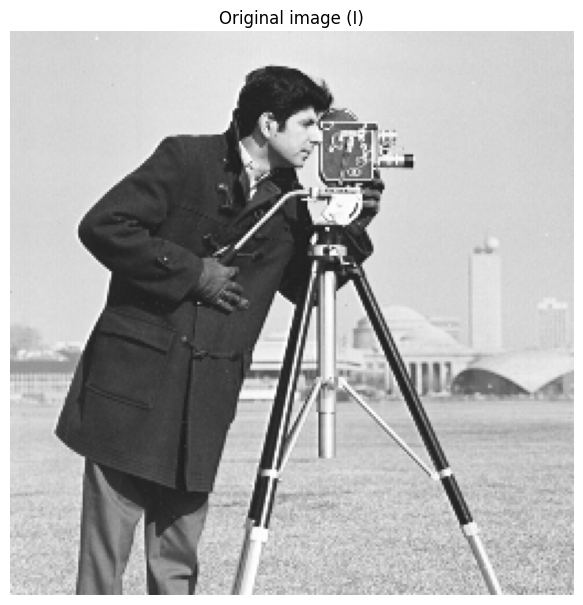

In [82]:
img_path = "cman.tif"
I = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if I is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")

print(f"Shape: {I.shape}, dtype: {I.dtype}, range: [{I.min()}, {I.max()}]")

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap="gray", vmin=0, vmax=255)
plt.title("Original image (I)")
plt.axis("off")

## Q2: Lượng tử hóa xuống 64

Quantized image J at 64 levels
Shape: (256, 256), dtype: uint8, range: [20, 252]


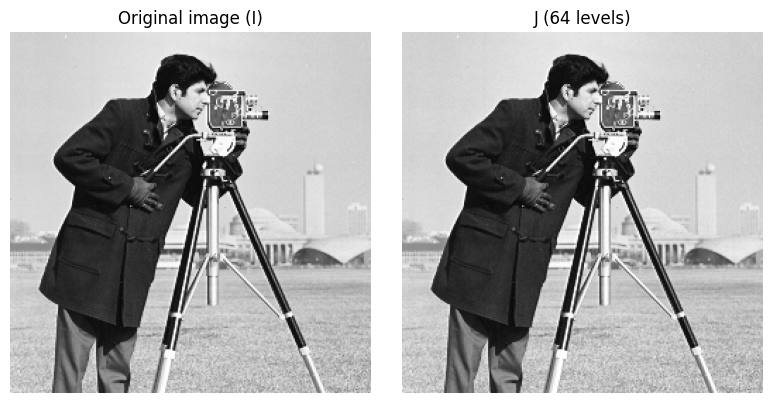

In [83]:
def quantize_levels(img, levels):
    if levels < 2:
        raise ValueError("levels must be >= 2")
    q = np.floor(img.astype(np.float32) / (256.0 / levels)) * (256.0 / levels)
    # q = np.clip(q, 0, levels - 1)
    # return np.round(q * (255.0 / (levels - 1))).astype(np.uint8)
    return q.astype(np.uint8)

J = quantize_levels(I, 64)

print("Quantized image J at 64 levels")
print(f"Shape: {J.shape}, dtype: {J.dtype}, range: [{J.min()}, {J.max()}]")
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap="gray",)
plt.title("Original image (I)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(J, cmap="gray")
plt.title("J (64 levels)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Q3: Lượng tử hóa J1 (8 mức) và J2 (128 mức)

Quantized image J1 at 8 levels
Shape: (256, 256), dtype: uint8, range: [0, 224]
Quantized image J2 at 128 levels
Shape: (256, 256), dtype: uint8, range: [20, 252]


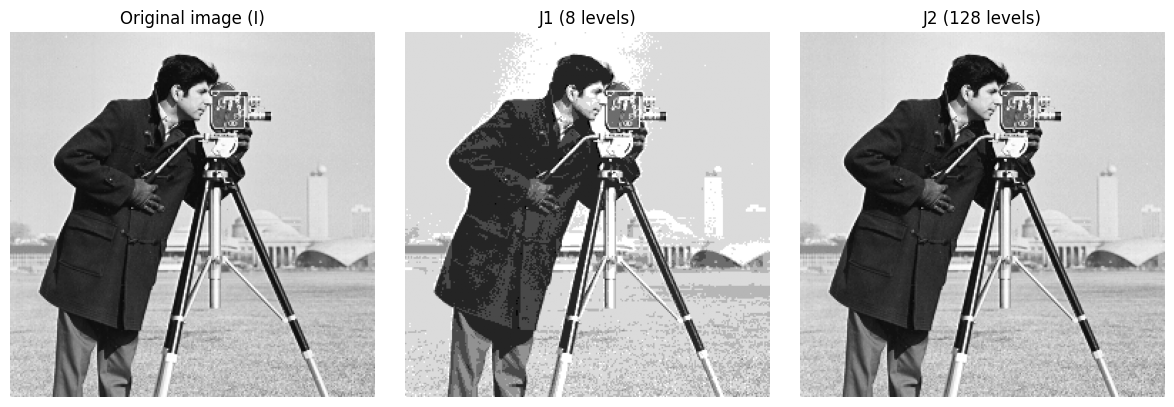

In [84]:
# create J1 (8 levels) and J2 (128 levels)
J1 = quantize_levels(J, 8)
J2 = quantize_levels(J, 128)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(I, cmap="gray")
plt.title("Original image (I)")
plt.axis("off")

print("Quantized image J1 at 8 levels")
print(f"Shape: {J1.shape}, dtype: {J1.dtype}, range: [{J1.min()}, {J1.max()}]")
plt.subplot(1, 3, 2)
plt.imshow(J1, cmap="gray")
plt.title("J1 (8 levels)")
plt.axis("off")

print("Quantized image J2 at 128 levels")
print(f"Shape: {J2.shape}, dtype: {J2.dtype}, range: [{J2.min()}, {J2.max()}]")
plt.subplot(1, 3, 3)
plt.imshow(J2, cmap="gray")
plt.title("J2 (128 levels)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Q4: Tính I_sub = |J1 - J2|

Computed I_sub = |J1 - J2|
I_sub range: [0, 28]


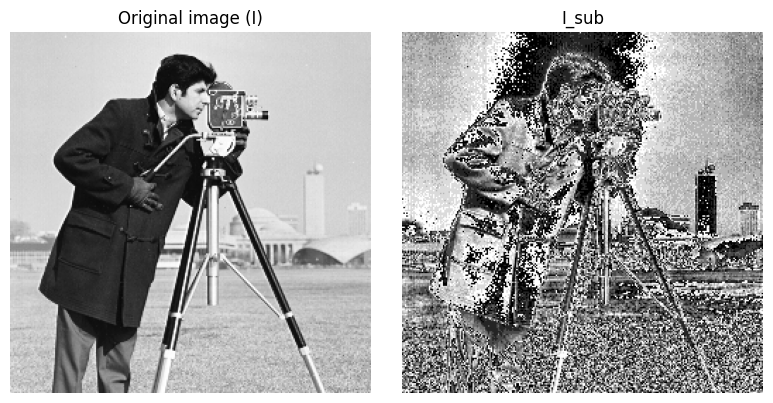

In [85]:
# I_sub = |J1 - J2|
I_sub = cv2.absdiff(J1, J2)

print("Computed I_sub = |J1 - J2|")
print(f"I_sub range: [{I_sub.min()}, {I_sub.max()}]")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap="gray")
plt.title("Original image (I)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(I_sub, cmap="gray")
plt.title("I_sub")
plt.axis("off")
plt.tight_layout()
plt.show()

## Q5: Hiệu chỉnh sáng (hàm mũ, logarit, tổng bình phương)

alpha=148.4041, beta=255.0000, gamma1=0.00196078, gamma2=0.00196078
I1 range: [13, 255], dtype: uint8
I2 range: [63, 255], dtype: uint8
I3 range: [8, 255], dtype: uint8


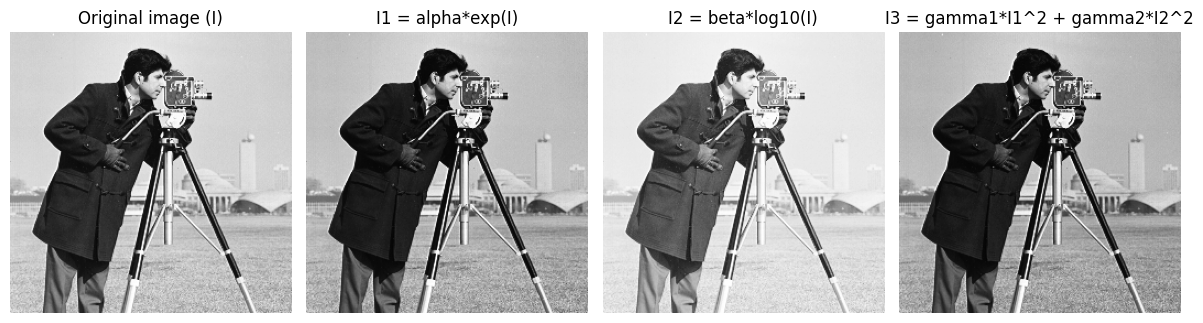

In [86]:
In = I.astype(np.float64) / 255

exp_term = np.exp(In) - 1.0
alpha = 255.0 / exp_term.max() 
I1 = alpha * exp_term

log_term = np.log10(1.0 + 9.0 * In)
beta = 255.0 / log_term.max() 
I2 = beta * log_term

gamma1 = 0.5 * 255.0 / np.max(I1 * I1)
gamma2 = 0.5 * 255.0 / np.max(I2 * I2)
I3 = gamma1 * (I1 * I1) + gamma2 * (I2 * I2)

I1 = I1.astype(np.uint8)
I2 = I2.astype(np.uint8)
I3 = I3.astype(np.uint8)

print(f"alpha={alpha:.4f}, beta={beta:.4f}, gamma1={gamma1:.8f}, gamma2={gamma2:.8f}")
print(f"I1 range: [{I1.min()}, {I1.max()}], dtype: {I1.dtype}")
print(f"I2 range: [{I2.min()}, {I2.max()}], dtype: {I2.dtype}")
print(f"I3 range: [{I3.min()}, {I3.max()}], dtype: {I3.dtype}")

plt.figure(figsize=(12, 8))
plt.subplot(1, 4, 1)
plt.imshow(I, cmap="gray")
plt.title("Original image (I)")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(I1, cmap="gray")
plt.title("I1 = alpha*exp(I)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(I2, cmap="gray")
plt.title("I2 = beta*log10(I)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(I3, cmap="gray")
plt.title("I3 = gamma1*I1^2 + gamma2*I2^2")
plt.axis("off")
plt.tight_layout()
plt.show()

## Q6: Chỉnh sáng theo hàm ``` f(I) = a*I^3 + b*I^2 + c*I + d ```

Coefficients: a=1.0, b=-0.9, c=1.3, d=-0.4


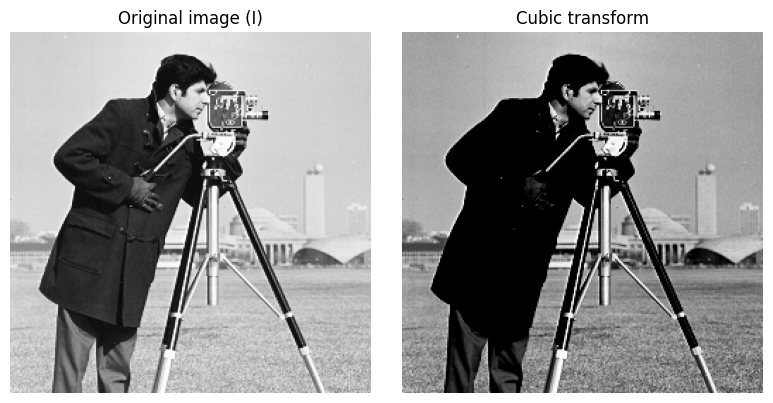

In [95]:
# f(I) = a*I^3 + b*I^2 + c*I + d
a, b, c, d = 1.0, -0.9, 1.3, -0.4
x = I.astype(np.float64) / 255.0
poly = a * (x ** 3) + b * (x ** 2) + c * x + d
poly = np.clip(poly, 0.0, 1.0)
I_poly = (poly * 255.0).astype(np.uint8)

print(f"Coefficients: a={a}, b={b}, c={c}, d={d}")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap="gray")
plt.title("Original image (I)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(I_poly, cmap="gray")
plt.title("Cubic transform")
plt.axis("off")
plt.tight_layout()
plt.show()

## Q7: Tăng sáng vùng đường tròn nội tiếp 

Doubled brightness inside the inscribed circle
Circle center: (128.0, 128.0), radius: 128.0


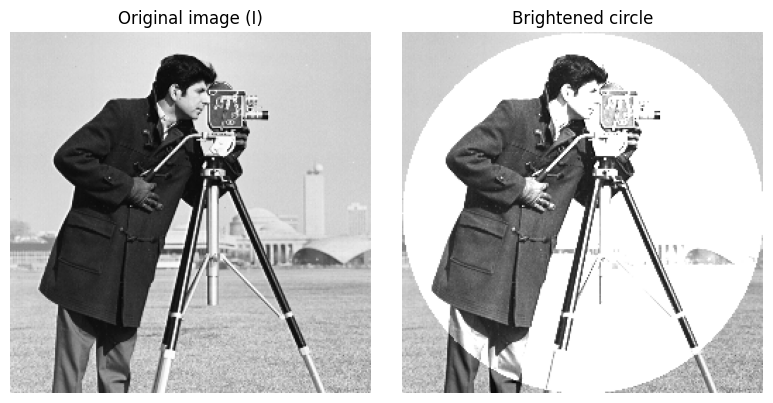

In [88]:
h, w = I.shape
cx, cy = w / 2.0, h / 2.0
r = min(h, w) / 2.0 
Y, X = np.ogrid[:h, :w]
mask_circle = (X - cx) ** 2 + (Y - cy) ** 2 <= r ** 2

I_circle = I.astype(np.float64).copy()
I_circle[mask_circle] = np.clip(2.0 * I_circle[mask_circle], 0, 255)
I_circle = I_circle.astype(np.uint8)

print("Doubled brightness inside the inscribed circle")
print(f"Circle center: ({cx:.1f}, {cy:.1f}), radius: {r:.1f}")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap="gray")
plt.title("Original image (I)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(I_circle, cmap="gray")
plt.title("Brightened circle")
plt.axis("off")
plt.tight_layout()
plt.show()